# 58 - 顔認識実験シリーズ: 総合まとめ

Notebook 51-57 の実験結果を総合的にまとめ、
CLIP/SigLIP によるテキスト→画像検索と顔 Embedding による人物検索を比較する。

## 実験シリーズの全体像
| No. | タイトル | 内容 |
|-----|---------|------|
| 51 | 顔検出の基礎 | InsightFace セットアップ、カテゴリ別検出統計 |
| 52 | Embedding + 保存 | 全378画像の顔Embedding → DuckDB |
| 53 | 顔類似検索 | terada → カンファレンス写真の同一人物検索 |
| 54 | クラスタリング | DBSCAN / Agglomerative による自動人物グループ化 |
| 55 | 定量評価 | Ground Truth + Precision/Recall/MRR/mAP |
| 56 | モデル比較 | InsightFace vs MediaPipe vs DeepFace |
| 57 | 大規模検索 | pyconjp 23,628枚での人物追跡 |
| 58 | 総合まとめ | 本ノートブック |

In [1]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from PIL import Image

## 設定

In [2]:
DB_PATH = Path("../data/images.duckdb")
FACE_DIM = 512
CLIP_DIM = 768

## 1. パイプライン概要

### 顔認識パイプライン
```
画像入力
    ↓
1. 顔検出 (SCRFD) → バウンディングボックス + 5点ランドマーク
    ↓
2. 顔アライメント → 正規化された顔画像
    ↓
3. Embedding (ArcFace) → 512次元ベクトル (正規化済み)
    ↓
4. DuckDB 保存 → face_detections テーブル (1画像 → 複数顔)
    ↓
5. HNSW 検索 → コサイン類似度で近い顔を発見
```

### キーポイント
- 1画像に複数の顔 → それぞれが独立した512次元ベクトル
- 「誰が写っているか」に特化（CLIP の「何が写っているか」とは異なる）

## 2. データの確認

In [3]:
conn = duckdb.connect(str(DB_PATH), read_only=True)
conn.execute("LOAD vss;")

# 基本統計
stats = {}
stats["総画像数"] = conn.execute("SELECT COUNT(*) FROM image_catalog").fetchone()[0]
stats["総検出顔数"] = conn.execute("SELECT COUNT(*) FROM face_detections").fetchone()[0]
stats["顔あり画像数"] = conn.execute("SELECT COUNT(DISTINCT image_id) FROM face_detections").fetchone()[0]
stats["平均顔数/画像"] = round(stats["総検出顔数"] / max(stats["顔あり画像数"], 1), 1)
stats["teradaラベル顔数"] = conn.execute("""
    SELECT COUNT(*) FROM face_detections WHERE person_label = 'terada'
""").fetchone()[0]
stats["クラスタ数"] = conn.execute("""
    SELECT COUNT(DISTINCT cluster_id) FROM face_detections WHERE cluster_id IS NOT NULL
""").fetchone()[0]

print("データ概要:")
for k, v in stats.items():
    print(f"  {k}: {v}")

データ概要:
  総画像数: 378
  総検出顔数: 75162
  顔あり画像数: 20473
  平均顔数/画像: 3.7
  teradaラベル顔数: 20
  クラスタ数: 60


## 3. CLIP 画像検索 vs 顔 Embedding 検索の比較

「terada を探す」タスクで、2つのアプローチを比較する:
- **CLIP**: テキスト "a portrait of a person" で画像を検索
- **顔Embedding**: terada の顔ベクトルで顔を検索

In [4]:
# CLIP による画像レベル検索（terada の画像 Embedding をクエリ）
terada_image_emb = conn.execute(f"""
    SELECT e.embedding
    FROM image_embeddings e
    JOIN image_catalog c ON e.id = c.id
    WHERE c.category = 'terada' AND e.model_name = 'openai/clip-vit-large-patch14'
    LIMIT 1
""").fetchone()

if terada_image_emb:
    clip_results = conn.execute(f"""
        SELECT 
            c.file_name, c.category, c.file_path,
            array_cosine_distance(e.embedding, ?::FLOAT[{CLIP_DIM}]) as distance
        FROM image_embeddings e
        JOIN image_catalog c ON e.id = c.id
        WHERE e.model_name = 'openai/clip-vit-large-patch14'
            AND c.category != 'terada'
        ORDER BY distance
        LIMIT 10
    """, [[float(x) for x in terada_image_emb[0]]]).fetchdf()

    clip_results["similarity"] = 1.0 - clip_results["distance"]
    print("CLIP 画像検索 Top-10 (terada 画像をクエリ):")
    display(clip_results[["file_name", "category", "similarity"]])
else:
    print("CLIP Embedding が見つかりません")
    clip_results = pd.DataFrame()

CLIP 画像検索 Top-10 (terada 画像をクエリ):


,file_name,category,similarity
0,2025-07-16 00.37.53.jpg,EuroPython2025,0.715323
1,2025-07-18 00.31.47.jpg,EuroPython2025,0.647902
2,1000042021.jpg,PyConJP2025,0.630693
3,2025-07-18 22.36.32.jpg,EuroPython2025,0.616967
4,2025-07-16 22.28.58.jpg,EuroPython2025,0.616597
5,2025-07-18 22.36.52.jpg,EuroPython2025,0.606131
6,2025-07-17 19.30.59.jpg,EuroPython2025,0.604865
7,2025-07-19 01.25.13.jpg,EuroPython2025,0.604336
8,2025-07-16 22.31.05.jpg,EuroPython2025,0.602633
9,2025-07-16 23.32.16.jpg,EuroPython2025,0.597759


In [5]:
# 顔 Embedding による検索
terada_face_emb = conn.execute(f"""
    SELECT f.embedding
    FROM face_detections f
    JOIN image_catalog c ON f.image_id = c.id
    WHERE c.category = 'terada'
    ORDER BY f.det_score DESC
    LIMIT 1
""").fetchone()

if terada_face_emb:
    face_results = conn.execute(f"""
        SELECT 
            c.file_name, c.category, c.file_path,
            f.bbox_x1, f.bbox_y1, f.bbox_x2, f.bbox_y2,
            f.person_label,
            array_cosine_distance(f.embedding, ?::FLOAT[{FACE_DIM}]) as distance
        FROM face_detections f
        JOIN image_catalog c ON f.image_id = c.id
        WHERE c.category != 'terada'
        ORDER BY distance
        LIMIT 10
    """, [[float(x) for x in terada_face_emb[0]]]).fetchdf()

    face_results["similarity"] = 1.0 - face_results["distance"]
    print("顔Embedding 検索 Top-10 (terada の顔をクエリ):")
    display(face_results[["file_name", "category", "similarity", "person_label"]])
else:
    print("顔 Embedding が見つかりません")
    face_results = pd.DataFrame()

顔Embedding 検索 Top-10 (terada の顔をクエリ):


,file_name,category,similarity,person_label
0,2025-07-16 18.40.31.jpg,EuroPython2025,0.792903,terada
1,2025-07-16 00.37.53.jpg,EuroPython2025,0.769677,terada
2,2025-09-27 15.23.34.jpg,PyConJP2025,0.743805,terada
3,2025-09-27 15.33.31.jpg,PyConJP2025,0.733281,terada
4,2025-07-18 00.31.47.jpg,EuroPython2025,0.725177,terada
5,1000042021.jpg,PyConJP2025,0.720939,terada
6,2025-09-27 15.23.35.jpg,PyConJP2025,0.698800,terada
7,2025-07-18 00.31.58.jpg,EuroPython2025,0.675665,terada
8,2025-04-27 20.37.56.jpg,TokyoNight202505,0.660618,terada
9,PXL_20250928_132045575.jpg,PyConJP2025,0.599783,terada


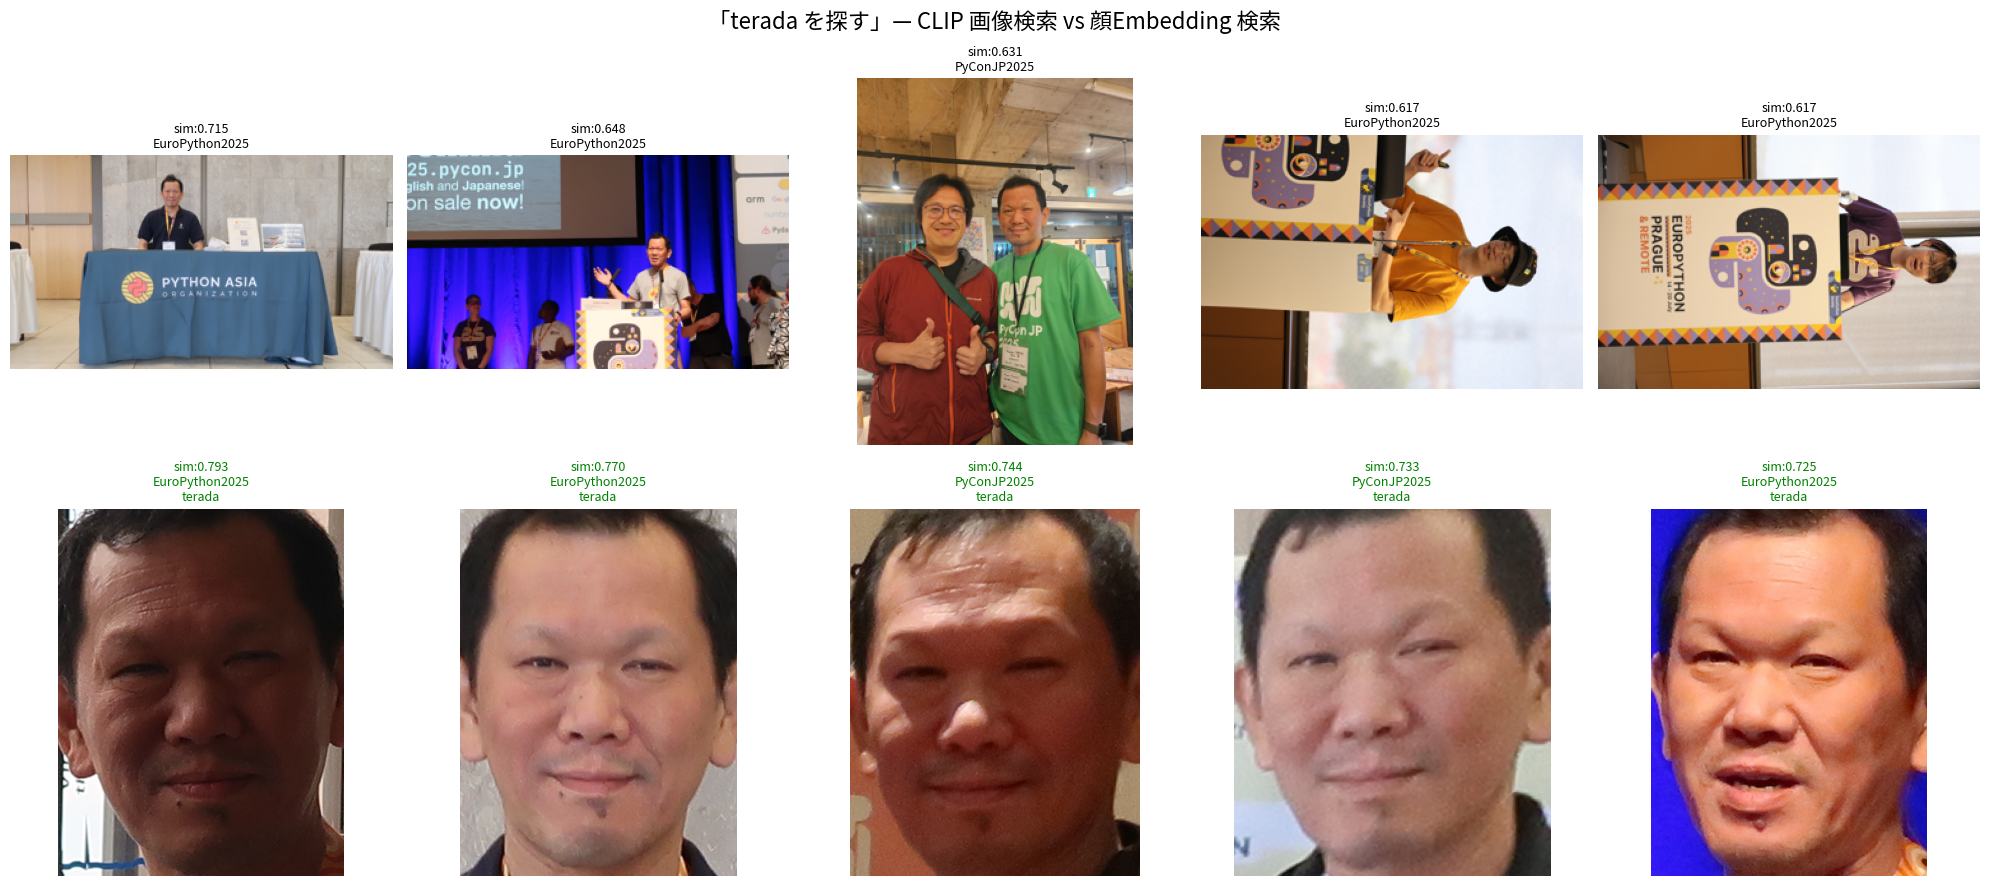

In [6]:
# サイドバイサイド比較の可視化
if len(clip_results) > 0 and len(face_results) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(20, 9))

    # CLIP 結果 (上段)
    for i in range(min(5, len(clip_results))):
        row = clip_results.iloc[i]
        try:
            img = Image.open(row["file_path"]).convert("RGB")
            img.thumbnail((300, 300))
            axes[0][i].imshow(img)
        except Exception:
            pass
        axes[0][i].set_title(f"sim:{row['similarity']:.3f}\n{row['category'][:15]}", fontsize=9)
        axes[0][i].axis("off")

    axes[0][0].set_ylabel("CLIP\n(画像レベル)", fontsize=14, rotation=0, labelpad=80, va="center")

    # 顔 Embedding 結果 (下段)
    for i in range(min(5, len(face_results))):
        row = face_results.iloc[i]
        try:
            img = Image.open(row["file_path"]).convert("RGB")
            # 顔クロップ
            x1 = max(0, int(row["bbox_x1"]) - 20)
            y1 = max(0, int(row["bbox_y1"]) - 20)
            x2 = min(img.width, int(row["bbox_x2"]) + 20)
            y2 = min(img.height, int(row["bbox_y2"]) + 20)
            face_crop = img.crop((x1, y1, x2, y2))
            axes[1][i].imshow(face_crop)
        except Exception:
            pass

        label = row.get("person_label", "")
        color = "green" if label == "terada" else "black"
        axes[1][i].set_title(f"sim:{row['similarity']:.3f}\n{row['category'][:15]}\n{label or ''}",
                             fontsize=9, color=color)
        axes[1][i].axis("off")

    axes[1][0].set_ylabel("ArcFace\n(顔レベル)", fontsize=14, rotation=0, labelpad=80, va="center")

    plt.suptitle("「terada を探す」— CLIP 画像検索 vs 顔Embedding 検索", fontsize=16)
    plt.tight_layout()
    plt.show()

## 4. 性能まとめ

In [7]:
# まとめテーブル
comparison = pd.DataFrame([
    {
        "手法": "CLIP-L (画像 Embedding)",
        "次元": 768,
        "粒度": "画像全体",
        "用途": "テキスト→画像 / 類似画像検索",
        "顔の識別": "不可（誰が写っているかは判別できない）",
        "複数人対応": "不可（画像全体で1ベクトル）",
    },
    {
        "手法": "ArcFace (顔 Embedding)",
        "次元": 512,
        "粒度": "個別の顔",
        "用途": "同一人物検索 / 人物追跡",
        "顔の識別": "可能（高精度な個人識別）",
        "複数人対応": "可能（1画像 → 複数ベクトル）",
    },
])

print("手法比較:")
display(comparison.T)

手法比較:


,0,1
手法,CLIP-L (画像 Embedding),ArcFace (顔 Embedding)
次元,768,512
粒度,画像全体,個別の顔
用途,テキスト→画像 / 類似画像検索,同一人物検索 / 人物追跡
顔の識別,不可（誰が写っているかは判別できない）,可能（高精度な個人識別）
複数人対応,不可（画像全体で1ベクトル）,可能（1画像 → 複数ベクトル）


## 5. 技術的知見

### InsightFace (buffalo_l) の特徴
- **検出**: SCRFD — 高精度、複数顔対応、ランドマーク付き
- **Embedding**: ArcFace 512次元 — 正規化済み、コサイン類似度で比較
- **属性**: 年齢・性別推定も同時取得
- **速度**: GPU (CUDA) で高速推論、CPU でも実用的

### DuckDB スキーマ設計
- `face_detections` テーブル: 1画像 → 複数顔 (1:N)
- `face_id` (UUID) で各顔を一意に識別
- HNSW インデックスで大規模データでも高速検索

### クラスタリング
- DBSCAN: ノイズ検出に優れ、クラスタ数の事前指定不要
- Agglomerative: コサイン距離閾値で柔軟に制御

### 閾値の重要性
- 同一人物判定にはコサイン類似度の閾値が重要
- F1 スコアの最大化により最適閾値を決定

### CLIP との使い分け
- **「何が写っている画像を探す」** → CLIP/SigLIP
- **「誰が写っている画像を探す」** → ArcFace 顔 Embedding
- 両方を組み合わせることで、より豊かな画像検索が可能

## 6. 制限事項と今後の方向性

### 制限事項
- 横顔や遮蔽された顔の検出は困難
- 小さい顔（群衆の奥など）は `det_size` を大きくしないと検出できない
- 年齢の経過による顔の変化は類似度を下げる
- 照明条件やカメラ角度の違いが影響

### 今後の方向性
- **JS (Transformers.js) での顔認識**: ブラウザ上での推論
- **動画対応**: フレーム抽出 → 顔追跡 → 人物識別
- **顔品質評価**: 低品質な顔を自動除外
- **CLIP + 顔の統合検索**: テキストで場面を絞り込み、顔で人物を特定
- **プライバシー対応**: 顔のぼかし・匿名化機能

In [8]:
conn.close()
print("顔認識実験シリーズ完了")

顔認識実験シリーズ完了
